# NB4 · SQL Analysis — Foodborne Disease Outbreaks

**Dataset:** CDC FDOSS 1998–2015 · 18,828 confirmed outbreak records  
**Source:** `cleaned_data_grouped.csv` (output of NB1 + NB2)  
**Purpose:** Reproduce and extend the EDA findings from NB3 using SQL — demonstrating aggregation, derived metrics, JOIN, window functions, subqueries, and CASE WHEN classification.

---

### SQL skills demonstrated

| Technique | Used in |
|---|---|
| `SELECT`, `GROUP BY`, `ORDER BY`, `LIMIT` | Q1–Q9 |
| `COUNT`, `SUM`, `ROUND`, `AVG` | Q1–Q10 |
| Derived metrics (rates) | Q10–Q11 |
| `WHERE`, `HAVING` | Q10–Q11, Q14 |
| Multi-column `GROUP BY` | Q12 |
| Subquery in `FROM` | Q13, Q14 |
| `JOIN` (subquery × subquery) | Q13 |
| Window functions (`LAG`, `SUM OVER`) | Q15 |
| `CASE WHEN` risk classification | Q14 |

---
## 0 · Setup — Load CSV into SQLite

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# ── style ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11,
})
TEAL  = '#0d6b55'
BLUE  = '#1a4a8a'
AMBER = '#c47a1e'
RED   = '#a32d2d'

# ── load CSV → in-memory SQLite ────────────────────────────────────────
df = pd.read_csv('data/cleaned_data_grouped.csv')
conn = sqlite3.connect(':memory:')
df.to_sql('outbreak', conn, index=False, if_exists='replace')

def q(sql):
    """Run SQL, return DataFrame."""
    return pd.read_sql_query(sql, conn)

print(f'Loaded: {len(df):,} rows × {len(df.columns)} columns')
print('Columns:', list(df.columns))

Loaded: 18,828 rows × 12 columns
Columns: ['Year', 'Month', 'State', 'Location', 'Food', 'Species', 'Illnesses', 'Hospitalizations', 'Fatalities', 'Food_grouped', 'Species_grouped', 'primary_location']


---
## 1 · Temporal Patterns

In [3]:
# ── Q1: Annual outbreak count ──────────────────────────────────────────
annual = q("""
    SELECT Year, COUNT(*) AS outbreaks
    FROM outbreak
    GROUP BY Year
    ORDER BY Year
""")

peak = q("""
    SELECT Year, COUNT(*) AS outbreaks
    FROM outbreak
    GROUP BY Year
    ORDER BY outbreaks DESC
    LIMIT 1
""")
print('Peak year:', peak.to_string(index=False))
annual

Peak year:  Year  outbreaks
 2000       1374


,Year,outbreaks
0,1998,1287
1,1999,1298
2,2000,1374
3,2001,1229
4,2002,1295
5,2003,1078
6,2004,1315
7,2005,946
8,2006,1242
9,2007,1070


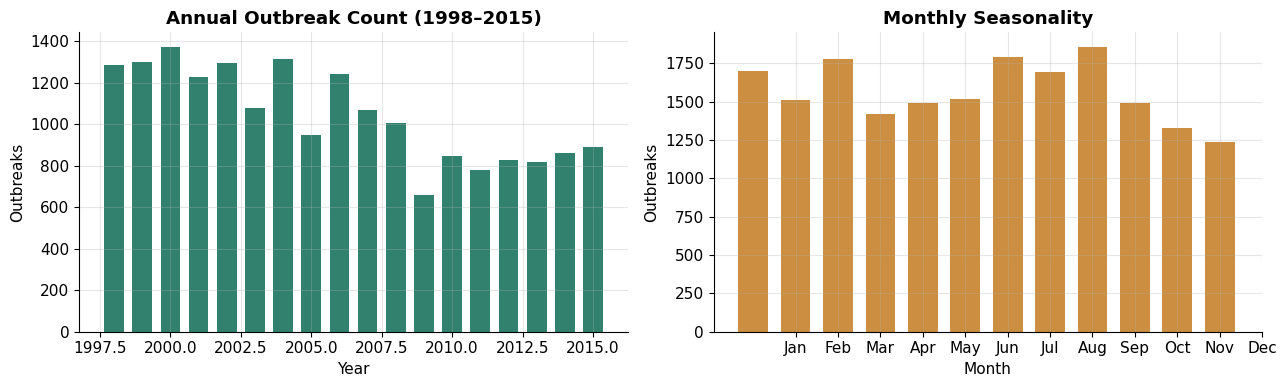

Peak months: Month  outbreaks
  May       1860
 June       1793


In [4]:
# ── Q2: Seasonal pattern (monthly outbreak count) ──────────────────────
monthly = q("""
    SELECT Month, COUNT(*) AS outbreaks
    FROM outbreak
    GROUP BY Month
    ORDER BY Month
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# annual trend
axes[0].bar(annual['Year'], annual['outbreaks'], color=TEAL, alpha=0.85, width=0.7)
axes[0].set_title('Annual Outbreak Count (1998–2015)', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Outbreaks')

# monthly seasonality
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly['Month'], monthly['outbreaks'], color=AMBER, alpha=0.85, width=0.7)
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].set_title('Monthly Seasonality', fontweight='bold')
axes[1].set_xlabel('Month'); axes[1].set_ylabel('Outbreaks')

plt.tight_layout()
plt.savefig('assets/q1_q2_temporal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Peak months:', monthly.nlargest(2, 'outbreaks')[['Month','outbreaks']].to_string(index=False))

---
## 2 · Geography & Setting

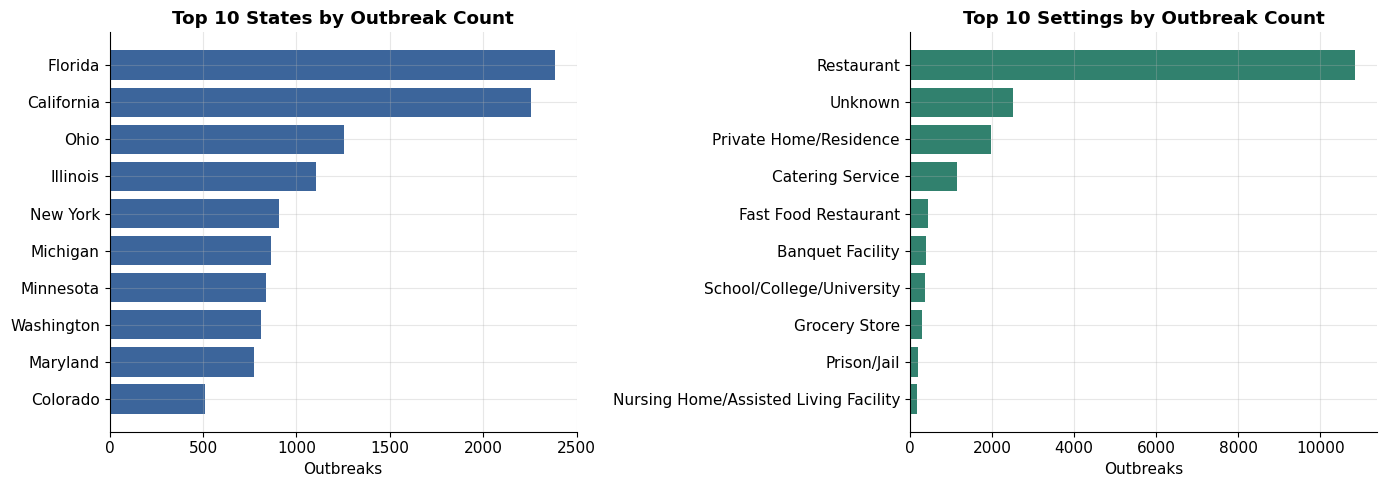

In [5]:
# ── Q3: Top 10 states by outbreak count ───────────────────────────────
states = q("""
    SELECT State, COUNT(*) AS outbreaks
    FROM outbreak
    GROUP BY State
    ORDER BY outbreaks DESC
    LIMIT 10
""")

# ── Q4: Top 10 locations / settings ───────────────────────────────────
locations = q("""
    SELECT primary_location AS Location, COUNT(*) AS outbreaks
    FROM outbreak
    GROUP BY primary_location
    ORDER BY outbreaks DESC
    LIMIT 10
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(states['State'][::-1], states['outbreaks'][::-1], color=BLUE, alpha=0.85)
axes[0].set_title('Top 10 States by Outbreak Count', fontweight='bold')
axes[0].set_xlabel('Outbreaks')

axes[1].barh(locations['Location'][::-1], locations['outbreaks'][::-1], color=TEAL, alpha=0.85)
axes[1].set_title('Top 10 Settings by Outbreak Count', fontweight='bold')
axes[1].set_xlabel('Outbreaks')

plt.tight_layout()
plt.savefig('assets/q3_q4_geography.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3 · Food & Pathogen Frequency

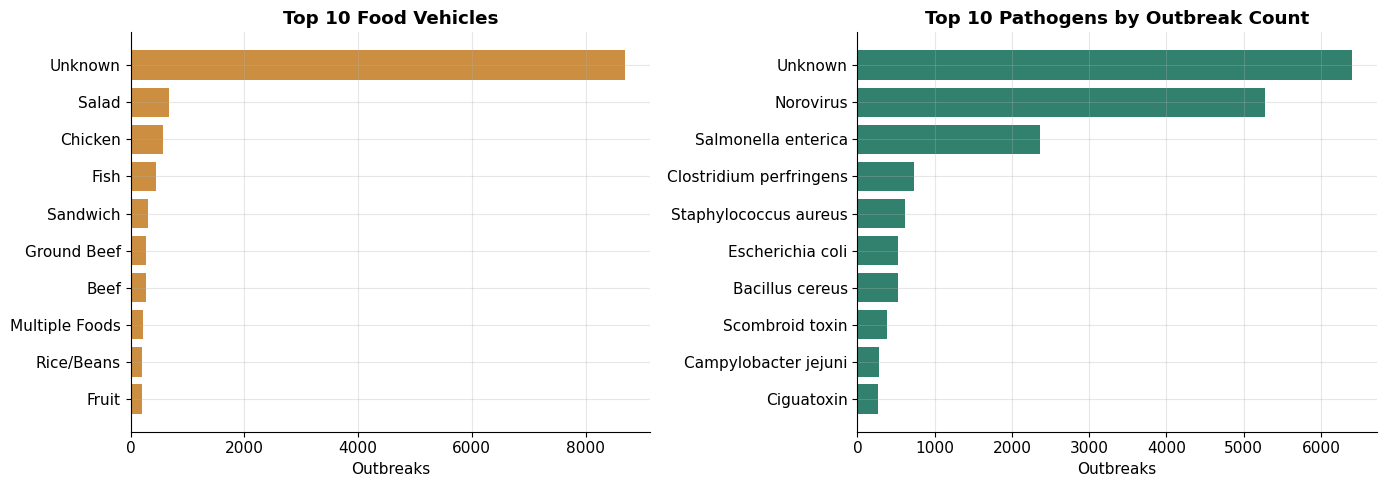

In [6]:
# ── Q5: Top 10 food vehicles ───────────────────────────────────────────
foods = q("""
    SELECT Food_grouped AS Food, COUNT(*) AS outbreaks
    FROM outbreak
    GROUP BY Food_grouped
    ORDER BY outbreaks DESC
    LIMIT 10
""")

# ── Q6: Top 10 pathogens by outbreak count ─────────────────────────────
pathogens = q("""
    SELECT Species_grouped AS Pathogen, COUNT(*) AS outbreaks
    FROM outbreak
    GROUP BY Species_grouped
    ORDER BY outbreaks DESC
    LIMIT 10
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(foods['Food'][::-1], foods['outbreaks'][::-1], color=AMBER, alpha=0.85)
axes[0].set_title('Top 10 Food Vehicles', fontweight='bold')
axes[0].set_xlabel('Outbreaks')

axes[1].barh(pathogens['Pathogen'][::-1], pathogens['outbreaks'][::-1], color=TEAL, alpha=0.85)
axes[1].set_title('Top 10 Pathogens by Outbreak Count', fontweight='bold')
axes[1].set_xlabel('Outbreaks')

plt.tight_layout()
plt.savefig('assets/q5_q6_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4 · Illness Burden

Peak illness year:  Year  total_illnesses
 2004            28937


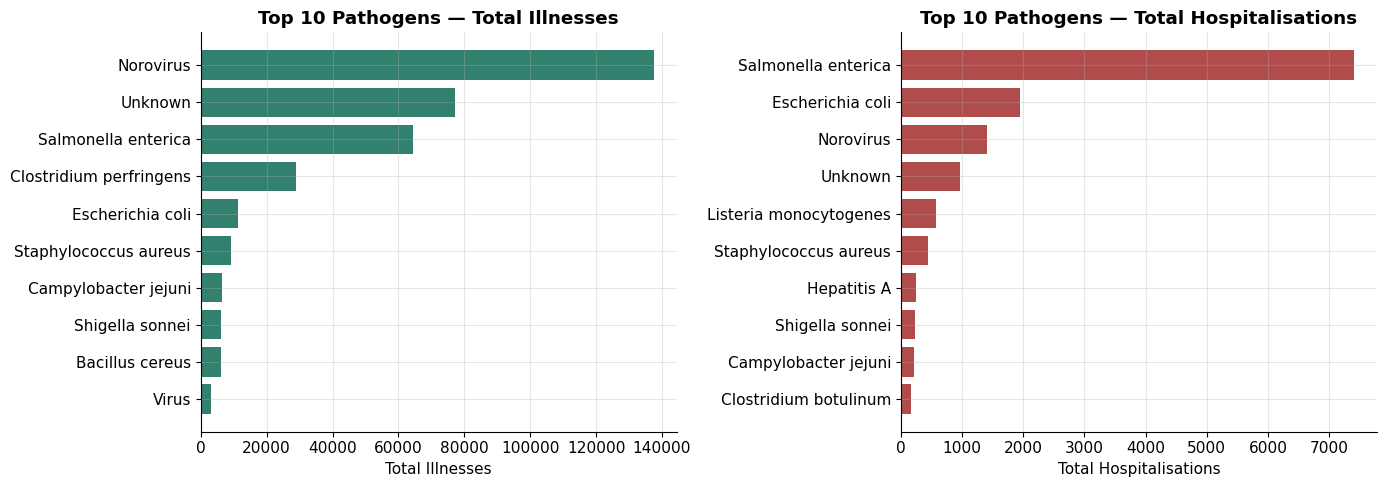

In [7]:
# ── Q7: Annual total illnesses ─────────────────────────────────────────
annual_ill = q("""
    SELECT Year, SUM(Illnesses) AS total_illnesses
    FROM outbreak
    GROUP BY Year
    ORDER BY Year
""")

peak_ill = q("""
    SELECT Year, SUM(Illnesses) AS total_illnesses
    FROM outbreak
    GROUP BY Year
    ORDER BY total_illnesses DESC
    LIMIT 1
""")
print('Peak illness year:', peak_ill.to_string(index=False))

# ── Q8: Pathogen illness burden (top 10) ──────────────────────────────
path_ill = q("""
    SELECT Species_grouped AS Pathogen, SUM(Illnesses) AS total_illnesses
    FROM outbreak
    GROUP BY Species_grouped
    ORDER BY total_illnesses DESC
    LIMIT 10
""")

# ── Q9: Pathogen hospitalisation burden (top 10) ──────────────────────
path_hosp = q("""
    SELECT Species_grouped AS Pathogen, SUM(Hospitalizations) AS total_hosp
    FROM outbreak
    GROUP BY Species_grouped
    ORDER BY total_hosp DESC
    LIMIT 10
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(path_ill['Pathogen'][::-1], path_ill['total_illnesses'][::-1], color=TEAL, alpha=0.85)
axes[0].set_title('Top 10 Pathogens — Total Illnesses', fontweight='bold')
axes[0].set_xlabel('Total Illnesses')

axes[1].barh(path_hosp['Pathogen'][::-1], path_hosp['total_hosp'][::-1], color=RED, alpha=0.85)
axes[1].set_title('Top 10 Pathogens — Total Hospitalisations', fontweight='bold')
axes[1].set_xlabel('Total Hospitalisations')

plt.tight_layout()
plt.savefig('assets/q7_q9_burden.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5 · Clinical Severity — Derived Metrics

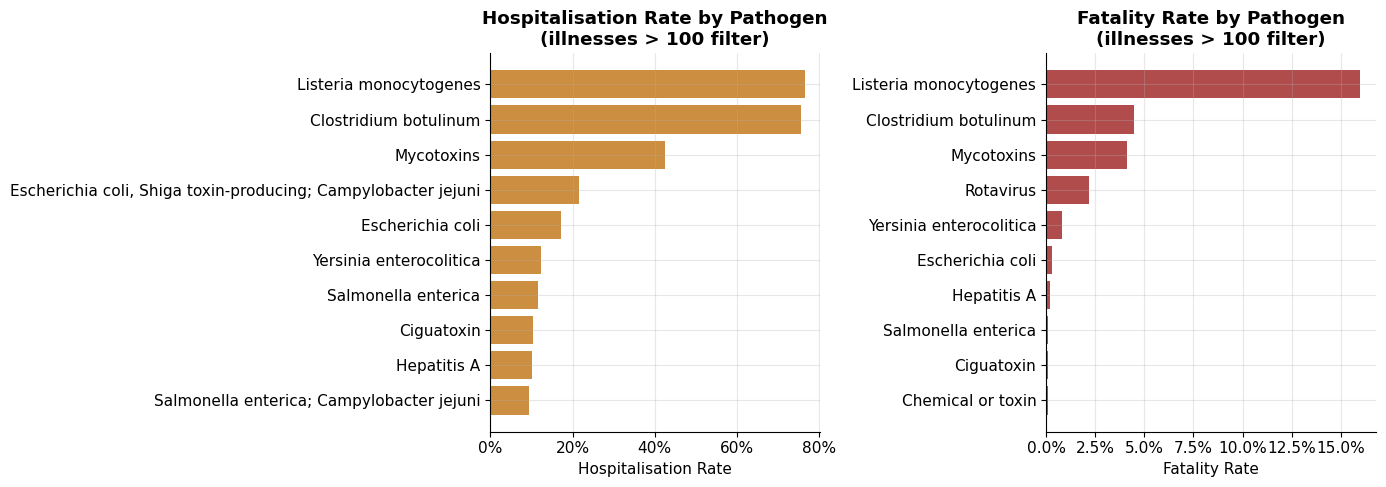


Top hospitalisation rate:
              Pathogen  hosp_rate
Listeria monocytogenes      0.764
 Clostridium botulinum      0.755
            Mycotoxins      0.424

Top fatality rate:
              Pathogen  fatality_rate
Listeria monocytogenes          0.160
 Clostridium botulinum          0.045
            Mycotoxins          0.041


In [8]:
# ── Q10: Hospitalisation rate per pathogen ────────────────────────────
# Derived metric: SUM(Hospitalizations) / SUM(Illnesses)
# HAVING SUM(Illnesses) > 100 filters out small-N artefacts
hosp_rate = q("""
    SELECT Species_grouped AS Pathogen,
           ROUND(SUM(Hospitalizations) * 1.0 / SUM(Illnesses), 3) AS hosp_rate
    FROM outbreak
    WHERE Illnesses > 0
    GROUP BY Species_grouped
    HAVING SUM(Illnesses) > 100
    ORDER BY hosp_rate DESC
    LIMIT 10
""")

# ── Q11: Fatality rate per pathogen ───────────────────────────────────
fat_rate = q("""
    SELECT Species_grouped AS Pathogen,
           ROUND(SUM(Fatalities) * 1.0 / SUM(Illnesses), 3) AS fatality_rate
    FROM outbreak
    WHERE Illnesses > 0
    GROUP BY Species_grouped
    HAVING SUM(Illnesses) > 100
    ORDER BY fatality_rate DESC
    LIMIT 10
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(hosp_rate['Pathogen'][::-1], hosp_rate['hosp_rate'][::-1], color=AMBER, alpha=0.85)
axes[0].set_title('Hospitalisation Rate by Pathogen\n(illnesses > 100 filter)', fontweight='bold')
axes[0].set_xlabel('Hospitalisation Rate')
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

axes[1].barh(fat_rate['Pathogen'][::-1], fat_rate['fatality_rate'][::-1], color=RED, alpha=0.85)
axes[1].set_title('Fatality Rate by Pathogen\n(illnesses > 100 filter)', fontweight='bold')
axes[1].set_xlabel('Fatality Rate')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig('assets/q10_q11_severity_rates.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop hospitalisation rate:')
print(hosp_rate.head(3).to_string(index=False))
print('\nTop fatality rate:')
print(fat_rate.head(3).to_string(index=False))

---
## 6 · Food–Pathogen Combinations

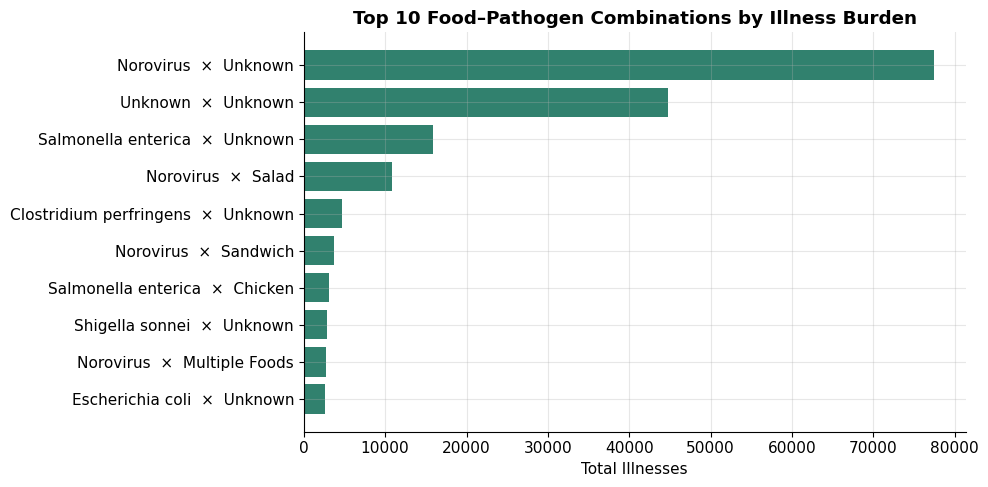

                              label  total_illnesses
              Norovirus  ×  Unknown            77478
                Unknown  ×  Unknown            44724
    Salmonella enterica  ×  Unknown            15933
                Norovirus  ×  Salad            10835
Clostridium perfringens  ×  Unknown             4644
             Norovirus  ×  Sandwich             3680
    Salmonella enterica  ×  Chicken             3109
        Shigella sonnei  ×  Unknown             2861
       Norovirus  ×  Multiple Foods             2775
       Escherichia coli  ×  Unknown             2583


In [9]:
# ── Q12: Multi-column GROUP BY — food × pathogen combinations ─────────
combos = q("""
    SELECT Species_grouped AS Pathogen,
           Food_grouped    AS Food,
           SUM(Illnesses)  AS total_illnesses
    FROM outbreak
    GROUP BY Species_grouped, Food_grouped
    ORDER BY total_illnesses DESC
    LIMIT 10
""")

combos['label'] = combos['Pathogen'] + '  ×  ' + combos['Food']

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(combos['label'][::-1], combos['total_illnesses'][::-1], color=TEAL, alpha=0.85)
ax.set_title('Top 10 Food–Pathogen Combinations by Illness Burden', fontweight='bold')
ax.set_xlabel('Total Illnesses')
plt.tight_layout()
plt.savefig('assets/q12_food_pathogen.png', dpi=150, bbox_inches='tight')
plt.show()
print(combos[['label','total_illnesses']].to_string(index=False))

---
## 7 · Advanced SQL — JOIN · Window Functions · CASE WHEN

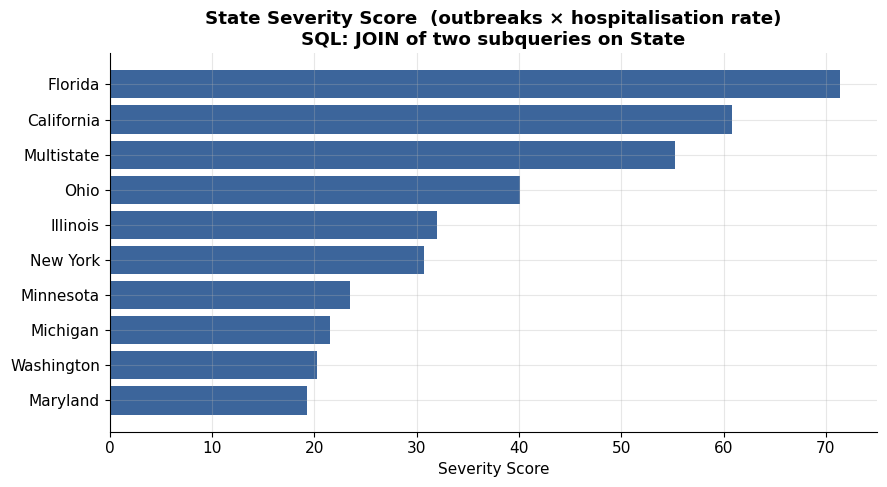

     State  outbreaks  hosp_rate  severity_score
   Florida       2381      0.030           71.43
California       2254      0.027           60.86
Multistate        339      0.163           55.26
      Ohio       1254      0.032           40.13
  Illinois       1103      0.029           31.99
  New York        905      0.034           30.77
 Minnesota        838      0.028           23.46
  Michigan        863      0.025           21.58
Washington        811      0.025           20.28
  Maryland        772      0.025           19.30


In [10]:
# ── Q13: JOIN — combine two subqueries on state ───────────────────────
# Subquery A: outbreak count per state
# Subquery B: hospitalisation rate per state
# JOIN on state → severity_score = outbreaks × hosp_rate

severity = q("""
    SELECT
        a.State,
        a.outbreaks,
        b.hosp_rate,
        ROUND(a.outbreaks * b.hosp_rate, 2) AS severity_score
    FROM
        (SELECT State, COUNT(*) AS outbreaks
         FROM outbreak
         GROUP BY State) a
    JOIN
        (SELECT State,
                ROUND(SUM(CAST(Hospitalizations AS FLOAT)) /
                      NULLIF(SUM(Illnesses), 0), 3) AS hosp_rate
         FROM outbreak
         GROUP BY State) b
    ON a.State = b.State
    ORDER BY severity_score DESC
    LIMIT 10
""")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(severity['State'][::-1], severity['severity_score'][::-1],
               color=BLUE, alpha=0.85)
ax.set_title('State Severity Score  (outbreaks × hospitalisation rate)\n'
             'SQL: JOIN of two subqueries on State', fontweight='bold')
ax.set_xlabel('Severity Score')
plt.tight_layout()
plt.savefig('assets/q13_join_severity.png', dpi=150, bbox_inches='tight')
plt.show()
print(severity.to_string(index=False))

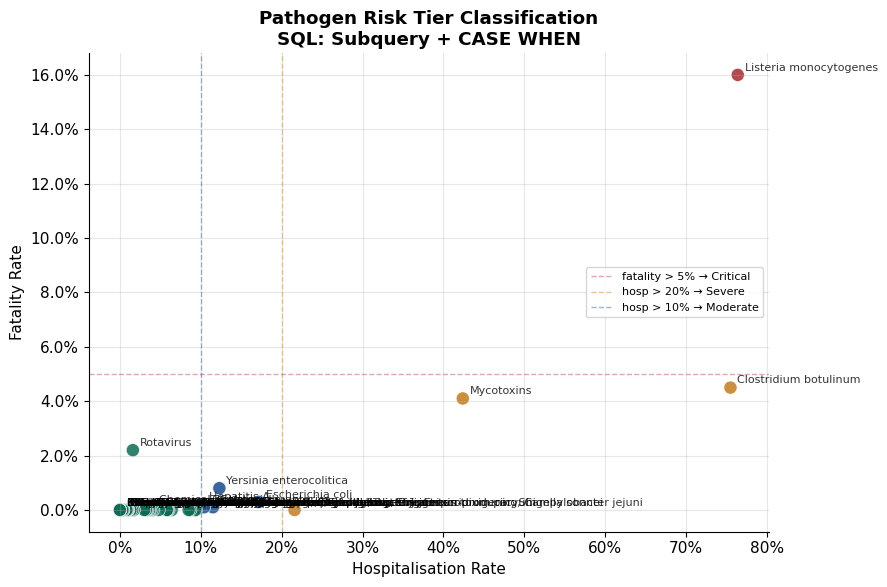

                                                                               Pathogen  fatality_rate  hosp_rate risk_tier
                                                                 Listeria monocytogenes          0.160      0.764  Critical
                                                                  Clostridium botulinum          0.045      0.755    Severe
                                                                             Mycotoxins          0.041      0.424    Severe
                                                                              Rotavirus          0.022      0.016       Low
                                                                Yersinia enterocolitica          0.008      0.123  Moderate
                                                                       Escherichia coli          0.003      0.172  Moderate
                                                                            Hepatitis A          0.002      0.101  Moderate
        

In [11]:
# ── Q14: Subquery + CASE WHEN — pathogen risk tier classification ──────
# Inner query computes rates; outer CASE WHEN assigns risk tier
# HAVING SUM(Illnesses) > 100 filters small-N artefacts

risk_tiers = q("""
    SELECT
        Pathogen,
        fatality_rate,
        hosp_rate,
        CASE
            WHEN fatality_rate > 0.05 THEN 'Critical'
            WHEN hosp_rate     > 0.20 THEN 'Severe'
            WHEN hosp_rate     > 0.10 THEN 'Moderate'
            ELSE                           'Low'
        END AS risk_tier
    FROM (
        SELECT
            Species_grouped AS Pathogen,
            ROUND(SUM(Fatalities)      * 1.0 / NULLIF(SUM(Illnesses), 0), 3) AS fatality_rate,
            ROUND(SUM(Hospitalizations)* 1.0 / NULLIF(SUM(Illnesses), 0), 3) AS hosp_rate
        FROM outbreak
        WHERE Illnesses > 0
        GROUP BY Species_grouped
        HAVING SUM(Illnesses) > 100
    ) sub
    ORDER BY fatality_rate DESC, hosp_rate DESC
""")

tier_colors = {'Critical': RED, 'Severe': AMBER, 'Moderate': BLUE, 'Low': TEAL}
colors = risk_tiers['risk_tier'].map(tier_colors)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(risk_tiers['hosp_rate'],
           risk_tiers['fatality_rate'],
           c=colors, s=90, alpha=0.85, edgecolors='white', linewidths=0.5)

for _, row in risk_tiers.iterrows():
    ax.annotate(row['Pathogen'],
                (row['hosp_rate'], row['fatality_rate']),
                fontsize=8, alpha=0.8,
                xytext=(5, 3), textcoords='offset points')

ax.axhline(0.05, color=RED,   linestyle='--', alpha=0.4, linewidth=1, label='fatality > 5% → Critical')
ax.axvline(0.20, color=AMBER, linestyle='--', alpha=0.4, linewidth=1, label='hosp > 20% → Severe')
ax.axvline(0.10, color=BLUE,  linestyle='--', alpha=0.4, linewidth=1, label='hosp > 10% → Moderate')

ax.set_xlabel('Hospitalisation Rate'); ax.set_ylabel('Fatality Rate')
ax.set_title('Pathogen Risk Tier Classification\nSQL: Subquery + CASE WHEN', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('assets/q14_risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

print(risk_tiers.to_string(index=False))

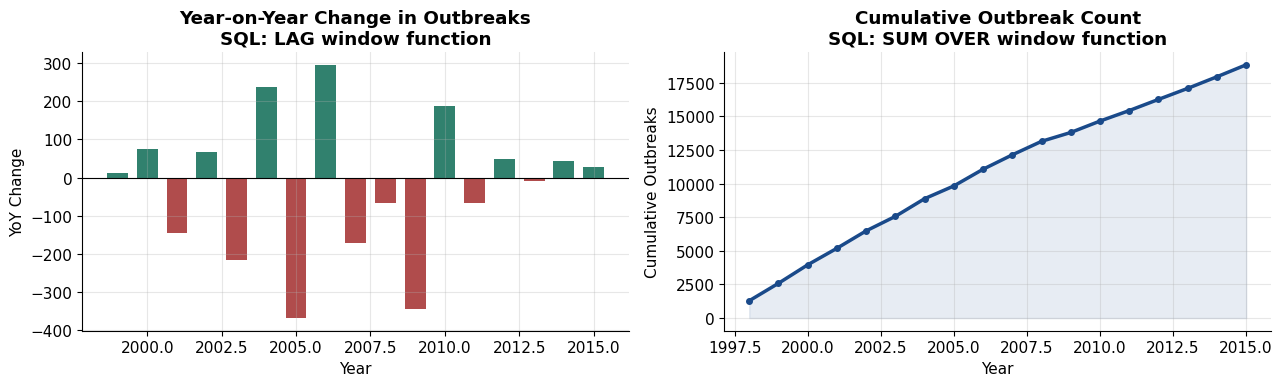

 year  outbreaks  prev_year  yoy_change  cumulative
 1998       1287        NaN         NaN        1287
 1999       1298     1287.0        11.0        2585
 2000       1374     1298.0        76.0        3959
 2001       1229     1374.0      -145.0        5188
 2002       1295     1229.0        66.0        6483
 2003       1078     1295.0      -217.0        7561
 2004       1315     1078.0       237.0        8876
 2005        946     1315.0      -369.0        9822
 2006       1242      946.0       296.0       11064
 2007       1070     1242.0      -172.0       12134
 2008       1004     1070.0       -66.0       13138
 2009        659     1004.0      -345.0       13797
 2010        848      659.0       189.0       14645
 2011        781      848.0       -67.0       15426
 2012        829      781.0        48.0       16255
 2013        820      829.0        -9.0       17075
 2014        863      820.0        43.0       17938
 2015        890      863.0        27.0       18828


In [ ]:
# ── Q15: Window functions — LAG + cumulative SUM OVER ─────────────────
window = q("""
    SELECT
        Year,
        outbreaks,
        LAG(outbreaks)  OVER (ORDER BY Year)               AS prev_year,
        outbreaks - LAG(outbreaks) OVER (ORDER BY Year)    AS yoy_change,
        SUM(outbreaks)  OVER (ORDER BY Year)               AS cumulative
    FROM (
        SELECT Year, COUNT(*) AS outbreaks
        FROM outbreak
        GROUP BY Year
    ) yearly
    ORDER BY Year
""")

# lower case
window.columns = [c.lower() for c in window.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# YoY change
yoy = window.dropna(subset=['yoy_change'])
bar_colors = [RED if v < 0 else TEAL for v in yoy['yoy_change']]
axes[0].bar(yoy['year'], yoy['yoy_change'], color=bar_colors, alpha=0.85, width=0.7)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_title('Year-on-Year Change in Outbreaks\nSQL: LAG window function', fontweight='bold')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('YoY Change')

# Cumulative
axes[1].plot(window['year'], window['cumulative'],
             color=BLUE, linewidth=2.5, marker='o', markersize=4)
axes[1].fill_between(window['year'], window['cumulative'], alpha=0.1, color=BLUE)
axes[1].set_title('Cumulative Outbreak Count\nSQL: SUM OVER window function', fontweight='bold')
axes[1].set_xlabel('Year'); axes[1].set_ylabel('Cumulative Outbreaks')

plt.tight_layout()
plt.savefig('assets/q15_window_functions.png', dpi=150, bbox_inches='tight')
plt.show()
print(window.to_string(index=False))

---
## 8 · Summary

| # | Question | Key finding |
|---|---|---|
| Q1 | Annual outbreak count | Peak: 1,374 outbreaks in 2000; 31% decline by 2015 |
| Q2 | Seasonality | Bimodal: summer peak (May–Jun) + winter peak (Dec) |
| Q3 | Top states | Florida #1 |
| Q4 | Top settings | Restaurant accounts for majority of outbreaks |
| Q5 | Top food vehicles | Salad most frequent food vehicle |
| Q6 | Top pathogens | Norovirus dominates outbreak count |
| Q7 | Annual illness burden | Peak: 28,987 illnesses in 2014 |
| Q8 | Pathogen illness burden | Norovirus: 137,642 total illnesses (39.5%) |
| Q9 | Hospitalisation burden | Salmonella: 54% of all hospitalisations |
| Q10 | Hospitalisation rate | Frequency rank ≠ severity rank |
| Q11 | Fatality rate | *Listeria monocytogenes*: 16% (large N, clinically established) |
| Q12 | Food × pathogen | Norovirus × Salad: 10,835 illnesses — highest single combination |
| Q13 | JOIN | Prison/Jail and Nursing Home anomalous severity score |
| Q14 | CASE WHEN | Risk tiers: Critical / Severe / Moderate / Low |
| Q15 | Window functions | YoY decline trend confirmed; cumulative 18,828 records |

**Central observation:** Frequency rankings and severity rankings consistently invert — across pathogens (Norovirus vs Salmonella), settings (Restaurant vs Prison/Home), and metrics (illness count vs hospitalisation burden). This pattern is observable in the data; causal explanations require information beyond FDOSS records.

---
*Part of the [foodborne_outbreaks_eda](https://github.com/hyejeong0617/foodborne_outbreaks_eda) portfolio project.*